In [131]:
import pandas as pd

In [132]:
data=pd.read_csv('insurance.csv')

In [133]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [134]:
data.dropna().count()

age         1338
sex         1338
bmi         1338
children    1338
smoker      1338
region      1338
charges     1338
dtype: int64

In [135]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [136]:
if 0 in data['charges'].values:
    print('Present zero in data')
else: 
    print('Not present')

Not present


In [137]:
df_copy=data.copy()

In [179]:
core = df_copy.corr()
core

C:\Users\GS018418\AppData\Local\Temp\ipykernel_22648\2272050181.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  core = df_copy.corr()


,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [138]:
df_copy

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [139]:
print(data.isna().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [140]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [141]:
data.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

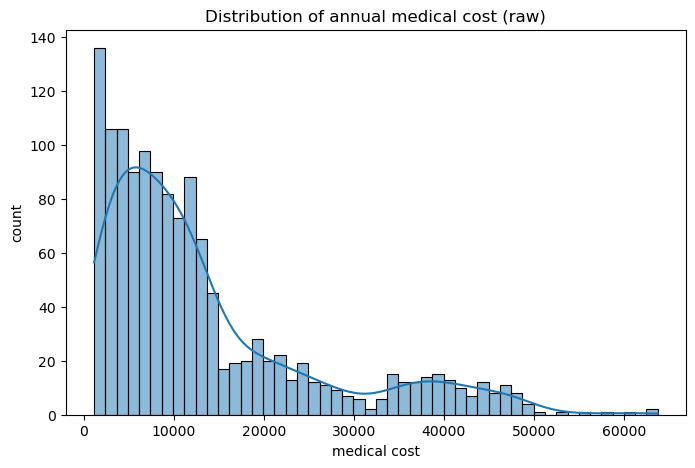

In [143]:
plt.figure(figsize=(8,5))
sns.histplot(data['charges'], bins=50, kde=True)
plt.title("Distribution of annual medical cost (raw)")
plt.xlabel("medical cost")
plt.ylabel("count")
plt.show()

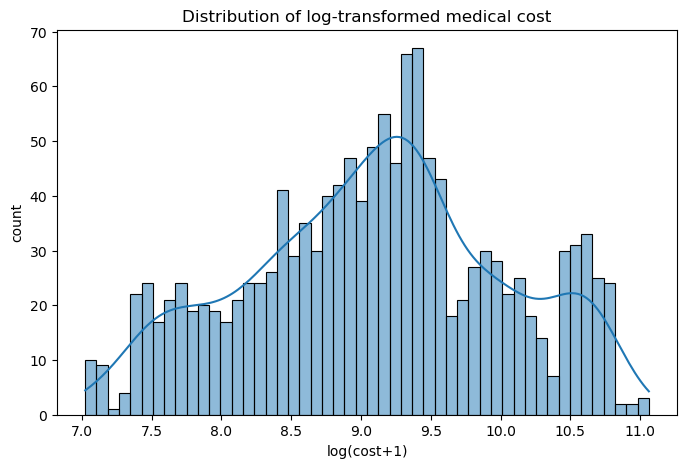

In [144]:
data['log_cost'] = np.log1p(data['charges'])
plt.figure(figsize=(8,5))
sns.histplot(data['log_cost'], bins=50, kde=True)
plt.title("Distribution of log-transformed medical cost")
plt.xlabel("log(cost+1)")
plt.ylabel("count")
plt.show()

In [145]:
percentiles = data['charges'].quantile([0.00001,0.5,0.75,0.9,0.95,0.99,0.999])
print(percentiles)

0.00001     1122.002689
0.50000     9382.033000
0.75000    16639.912515
0.90000    34831.719700
0.95000    41181.827787
0.99000    48537.480726
0.99900    61726.286312
Name: charges, dtype: float64


In [146]:
print(data['charges'].min())

1121.8739


In [147]:
data

,age,sex,bmi,children,smoker,region,charges,log_cost
0,19,female,27.900,0,yes,southwest,16884.92400,9.734236
1,18,male,33.770,1,no,southeast,1725.55230,7.453882
2,28,male,33.000,3,no,southeast,4449.46200,8.400763
3,33,male,22.705,0,no,northwest,21984.47061,9.998137
4,32,male,28.880,0,no,northwest,3866.85520,8.260455
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,9.268755
1334,18,female,31.920,0,no,northeast,2205.98080,7.699381
1335,18,female,36.850,0,no,southeast,1629.83350,7.396847
1336,21,female,25.800,0,no,southwest,2007.94500,7.605365


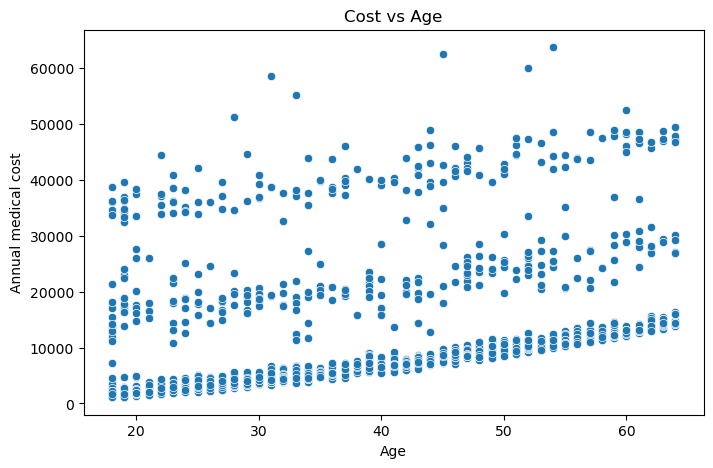

In [148]:
#relationship between age and charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=data)
plt.title("Cost vs Age")
plt.xlabel("Age")
plt.ylabel("Annual medical cost")
plt.show()

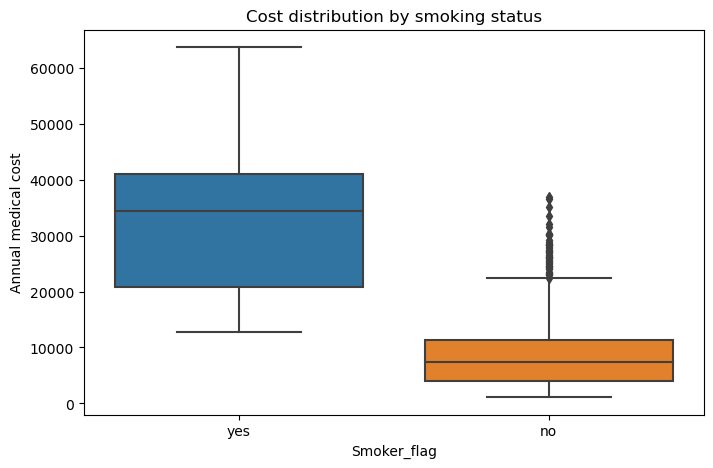

In [149]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title("Cost distribution by smoking status")
plt.xlabel("Smoker_flag")
plt.ylabel("Annual medical cost")
plt.show()

In [150]:
data["sex"] = data["sex"].map({"male": 1, "female": 0})
data["smoker"] = data["smoker"].map({"yes": 1, "no": 0})
data["region"] = data["region"].map({
    "northeast": 0,
    "northwest": 1,
    "southeast": 2,
    "southwest": 3
})

In [151]:
data

,age,sex,bmi,children,smoker,region,charges,log_cost
0,19,0,27.900,0,1,3,16884.92400,9.734236
1,18,1,33.770,1,0,2,1725.55230,7.453882
2,28,1,33.000,3,0,2,4449.46200,8.400763
3,33,1,22.705,0,0,1,21984.47061,9.998137
4,32,1,28.880,0,0,1,3866.85520,8.260455
...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830,9.268755
1334,18,0,31.920,0,0,0,2205.98080,7.699381
1335,18,0,36.850,0,0,2,1629.83350,7.396847
1336,21,0,25.800,0,0,3,2007.94500,7.605365


In [152]:
features=['age', 'sex', 'bmi', 'children', 'smoker', 'region']
X = data[features]
y = data['log_cost']

In [163]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [165]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [168]:
pred_test = lr.predict(X_test)
mae = mean_absolute_error(y_test, pred_test)
print("MAE:", mae)

MAE: 0.27077904040663536


In [169]:
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print("RMSE:", rmse)

RMSE: 0.4213031491748419


In [170]:
def predict_cost(age, sex, bmi, children, smoker, region):
    
    sex_val = 1 if sex == "male" else 0
    smoker_val = 1 if smoker == "yes" else 0
    region_map = {"northeast":0,"northwest":1,"southeast":2,"southwest":3}
    region_val = region_map[region]

    input_df = pd.DataFrame([{
        'age': age,
        'sex': sex_val,
        'bmi': bmi,
        'children': children,
        'smoker': smoker_val,
        'region': region_val
    }])

    log_pred = lr.predict(input_df)[0]         # predict log(charges)
    real_pred = np.exp(log_pred) - 1           # convert to original scale

    return real_pred

In [171]:
predict_cost(age=48, sex="male", bmi=31, children=1, smoker="no", region="northeast")

9116.2607068654

In [174]:
predict_cost(age=48, sex="male", bmi=31, children=1, smoker="no", region="southwest")

7980.69822907327

This shows the Northeast & Northwest typically have higher costs of care.

Southwest and Southeast has lower average provider charges.

In [172]:
import numpy as np
y_pred_log = lr.predict(X_test)
y_pred = np.exp(y_pred_log) - 1
y_true = np.exp(y_test) - 1
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("Model Accuracy (R²):", r2)
print("MAE:", mae)
print("RMSE:", rmse)

Model Accuracy (R²): 0.6029653837057418
MAE: 3909.135871326229
RMSE: 7851.0585616212675
